In [1]:
import os 
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

!nvidia-smi

Fri Aug 29 03:55:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.76.05              Driver Version: 580.76.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        Off |   00000000:19:00.0 Off |                  N/A |
| 88%   87C    P1            400W /  400W |    8631MiB /  32607MiB |     90%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from backbones.dit import DiT

# 사용 예
model = DiT()
print(model)

/home/scpark/miniconda3/envs/dual/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]An error occurred while trying to fetch /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/transformer: Error no file named diffusion_pytorch_model.safetensors found in directory /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/transformer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  33%|███▎      | 1/3 [00:00<00:00,  2.34it/s]An error occurred while trying to fetch /home/scpark/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def display_class_images(pixel_samples, class_ids=None, figsize_per_image=3.5, display_title=""):
    samples = list(pixel_samples)
    processed = []
    for img in samples:
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            arr = np.array(img)
            if arr.ndim == 3 and arr.shape[0] in (1,3):
                arr = arr.transpose(1, 2, 0)
        processed.append(arr)

    n = len(processed)
    if class_ids is None:
        class_ids = list(range(n))

    fig, axes = plt.subplots(1, n, figsize=(n * figsize_per_image, figsize_per_image))
    if n == 1:
        axes = [axes]

    # 전체 제목 추가
    if display_title:
        fig.suptitle(display_title, fontsize=10, y=1.1)  # y 값을 1.02로 올려서 제목을 위로 이동
    # 플롯 레이아웃 조정: top을 낮춰서 제목과 플롯 사이에 공간 확보
    
    for ax, img_arr, lbl in zip(axes, processed, class_ids):
        ax.imshow(img_arr)
        ax.axis("off")
        ax.set_title(f"Class {lbl}", fontsize=8)

    plt.show()


In [53]:
from solvers.others.dpm_solver import DPM_Solver
from solvers.others.euler_solver import Euler_Solver

# 클래스 0–9로 설정
class_start = np.random.randint(0, 900)
class_start = 300
class_ids = [i for i in range(class_start, class_start+100, 10)]
noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=class_ids, guidance_scale=3.0)
noises = model.get_noise(seeds=class_ids)


logs/ablations/clip/s5/step_00020000.pt


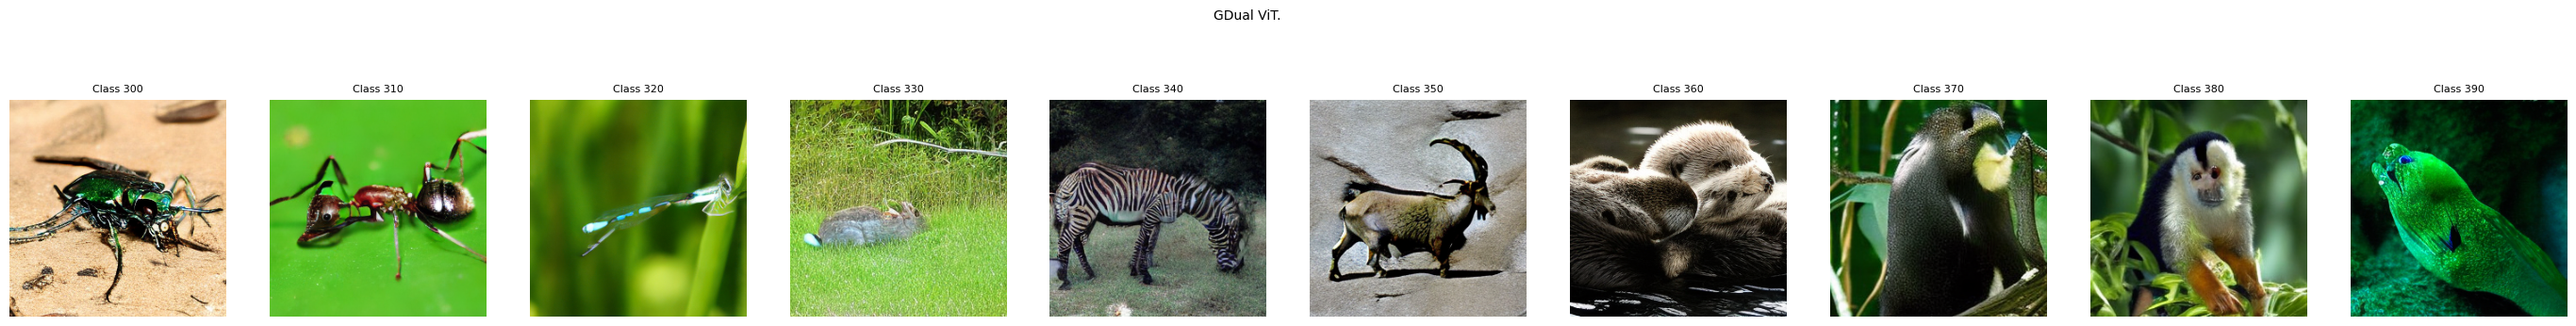

logs/dit/bns/s5/step_00003434.pt


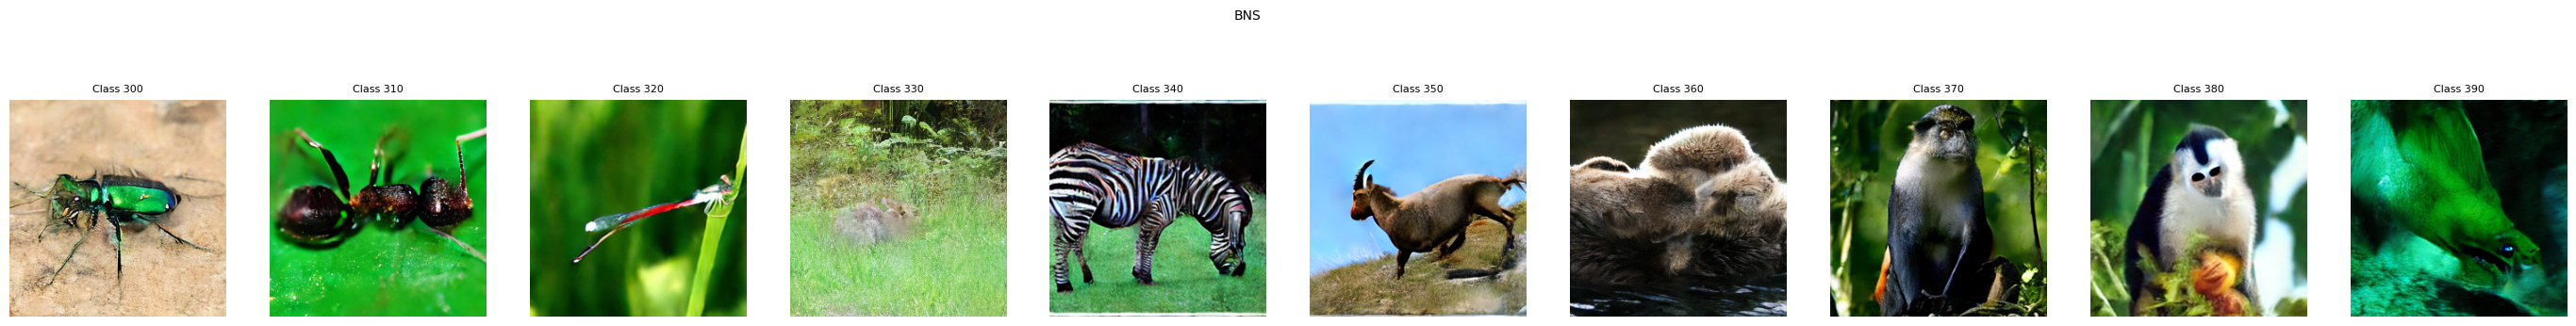

logs/dit/ds/ddpm/s5/step_00020000.pt


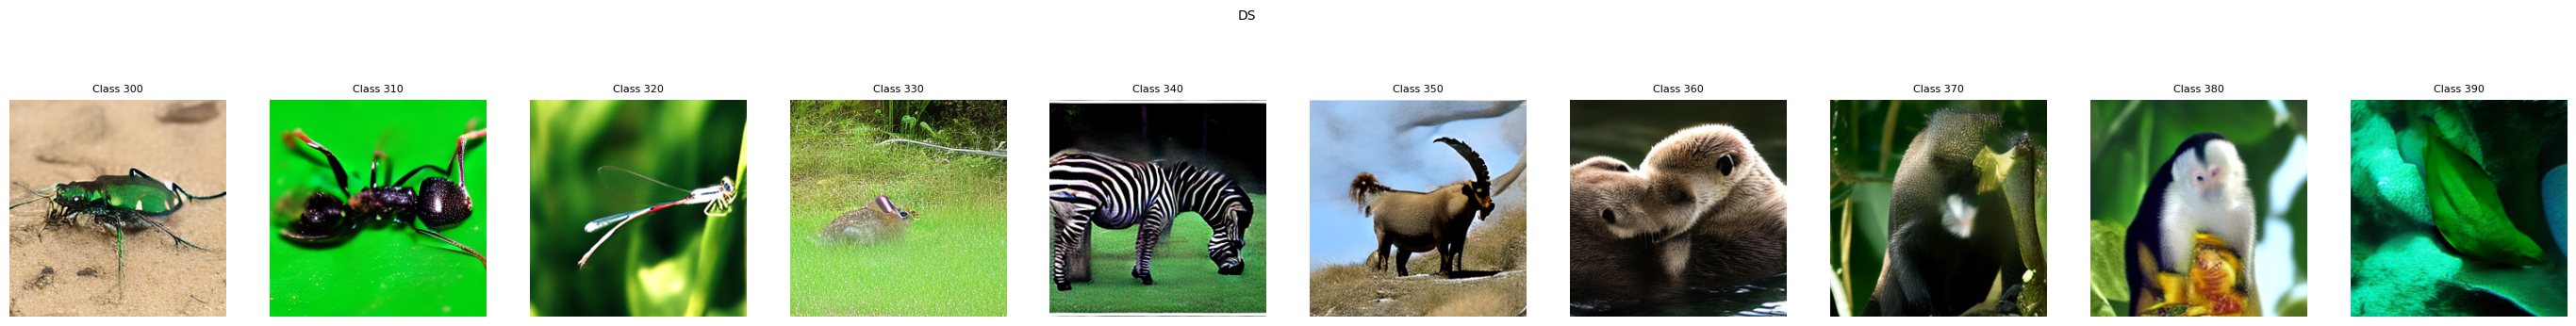

In [54]:
import torch
from utils.util import get_pt

NFE = 5

# solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
# latents = solver.sample(noises, model_fn)['samples']
# samples = model.decode_vae(latents, raw_output=False, pil_output=True)
# display_class_images(samples['pil_output'], class_ids, display_title='Euler')

# solver = DPM_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
# latents = solver.sample(noises, model_fn)['samples']
# samples = model.decode_vae(latents, raw_output=False, pil_output=True)
# display_class_images(samples['pil_output'], class_ids, display_title='DPM')

from solvers.taylor.solver.gdual_solver import GDual_Solver
from solvers.taylor.transform.logaffine_transform import LogAffineTransform
from solvers.taylor.extractor.table_extractor import Extractor
extractor = Extractor(steps=NFE)
transform = LogAffineTransform(gamma_push=True, gamma_max=2, tau_offset=1, kappa_max=2, eps=1e-2)
solver = GDual_Solver(
    noise_schedule,
    steps=NFE,
    transform=transform,
    param_extractor=extractor,
    skip_type="time_uniform",
    pred_order=1,
    corr_order=2,
    order1_kappa=True,
    order2_kappa=True,
    use_corrector=True,
    time_learning=True,
    train_mode=True
).to(model.device)

# with torch.no_grad():
#     latents = solver.sample(noises, model_fn)['samples']
#     samples = model.decode_vae(latents, raw_output=False, pil_output=True)
# display_class_images(samples['pil_output'], class_ids, display_title='GDual Init.')

pt_file = get_pt(f'logs/ablations/clip/s{NFE}', 'latest')
print(pt_file)
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    latents = solver.sample(noises, model_fn)['samples']
    samples = model.decode_vae(latents, raw_output=False, pil_output=True)
display_class_images(samples['pil_output'], class_ids, display_title='GDual ViT.')

from solvers.competing.bns.bns_solver import BNS_Solver
solver = BNS_Solver(
        noise_schedule,
        steps=NFE,
        skip_type="time_uniform",
    ).to(model.device)

pt_file = get_pt(f'logs/dit/bns/s{NFE}', 'latest')
print(pt_file)
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    latents = solver.sample(noises, model_fn)['samples']
    samples = model.decode_vae(latents, raw_output=False, pil_output=True)
display_class_images(samples['pil_output'], class_ids, display_title='BNS')

from solvers.competing.ds.ds_solver_ddpm import DS_Solver
solver = DS_Solver(
        noise_schedule,
        steps=NFE,
        skip_type="time_uniform",
    ).to(model.device)

pt_file = get_pt(f'logs/dit/ds/ddpm/s{NFE}', 'latest')
print(pt_file)
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    latents = solver.sample(noises, model_fn)['samples']
    samples = model.decode_vae(latents, raw_output=False, pil_output=True)
display_class_images(samples['pil_output'], class_ids, display_title='DS')
